In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as cp
import fluids as fl

In [2]:
df = pd.read_csv("datos_experimentales.csv")
df.head()

,masa,altura,temperatura,altura_piso,tiempo
0,386,20.6,14.8,13.5,20.0
1,562,20.6,14.0,13.5,30.0
2,499,40.0,13.8,13.5,30.0
3,592,40.0,13.8,13.5,30.0
4,518,60.0,13.8,13.5,30.0


In [3]:
df["altura"] *= 1e-2
df["masa"] *= 1e-3
df["altura_piso"] *= 1e-2
df["altura_total"] = df["altura"] + df["altura_piso"]
df["temperatura"] += 273.15

In [4]:
df["rho"] = df.apply(lambda x: cp.PropsSI("D", "T", x["temperatura"], "P", 101325, "Water"), axis = 1)
df["mu"] = df.apply(lambda x: cp.PropsSI("V", "T", x["temperatura"], "P", 101325, "Water"), axis = 1)
df["caudal"] = df["masa"]/df["tiempo"]/df["rho"]
df.head()

,masa,altura,temperatura,altura_piso,tiempo,altura_total,rho,mu,caudal
0,0.386,0.206,287.95,0.135,20.0,0.341,999.132527,0.001144,0.000019
1,0.562,0.206,287.15,0.135,30.0,0.341,999.247383,0.001168,0.000019
2,0.499,0.400,286.95,0.135,30.0,0.535,999.274895,0.001175,0.000017
3,0.592,0.400,286.95,0.135,30.0,0.535,999.274895,0.001175,0.000020
4,0.518,0.600,286.95,0.135,30.0,0.735,999.274895,0.001175,0.000017


In [5]:
d1 = 6.6e-3
d2 = 12e-3
l1 = 0.52
l2 = 5
df["v1"] = df["caudal"] / (np.pi*(d1/2)**2)
df["v2"] = df["caudal"] / (np.pi*(d2/2)**2)
df["re1"] = df.apply(lambda x: x["v1"]*x["rho"]*d1/x["mu"], axis=1)
df["re2"] = df.apply(lambda x: x["v2"]*x["rho"]*d2/x["mu"], axis=1)

In [6]:
roughness = fl.friction.material_roughness("Silicone")*1e-3
print(roughness)

1.5e-06


In [7]:

df["f1"] = df.apply(lambda x: fl.friction.friction_factor(x["re1"], roughness/d1), axis=1)
df["f2"] = df.apply(lambda x: fl.friction.friction_factor(x["re2"], roughness/d2), axis=1)

In [8]:
df["dp"] = df["altura_total"]*df["rho"]*9.81 + df["f1"]*0.5*df["rho"]*df["v1"]**2 + df["f2"]*0.5*df["rho"]*df["v2"]**2

In [9]:
df.head()

,masa,altura,temperatura,altura_piso,tiempo,altura_total,rho,mu,caudal,v1,v2,re1,re2,f1,f2,dp
0,0.386,0.206,287.95,0.135,20.0,0.341,999.132527,0.001144,0.000019,0.564620,0.170798,3255.690565,1790.629811,0.042657,0.035742,3349.622595
1,0.562,0.206,287.15,0.135,30.0,0.341,999.247383,0.001168,0.000019,0.547979,0.165764,3093.236298,1701.279964,0.043320,0.037619,3349.707977
2,0.499,0.400,286.95,0.135,30.0,0.535,999.274895,0.001175,0.000017,0.486538,0.147178,2731.721198,1502.446659,0.044993,0.042597,5250.326847
3,0.592,0.400,286.95,0.135,30.0,0.535,999.274895,0.001175,0.000020,0.577215,0.174608,3240.839577,1782.461767,0.042716,0.035905,5252.202169
4,0.518,0.600,286.95,0.135,30.0,0.735,999.274895,0.001175,0.000017,0.505063,0.152782,2835.734630,1559.654046,0.044480,0.041035,7211.269358


In [10]:
ndf = df.groupby("altura_total").agg({"dp":"mean", "caudal":"mean"})
ndf.head()
ndf["caudal_paralelo"] = ndf["caudal"]*2

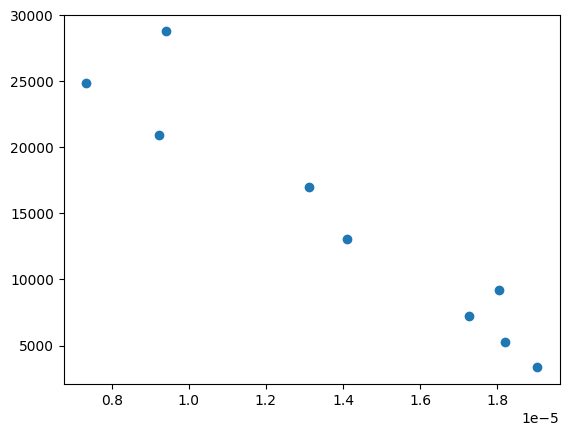

In [11]:
plt.scatter(ndf["caudal"], ndf["dp"]);

In [12]:
coefp= np.polyfit(ndf["caudal_paralelo"], ndf["dp"],2)
print(coefp)
pp = np.poly1d(coefp) # Crea una función evaluable con esos coeficientes

# 2. Generar puntos para una curva suave en el gráfico
x_curvap = np.linspace(min(ndf["caudal_paralelo"]), max(ndf["caudal_paralelo"]), 100)
y_curvap = pp(x_curvap)

[-1.29742768e+13 -2.73493629e+08  3.30978671e+04]


In [13]:
coef = np.polyfit(ndf["caudal"], ndf["dp"],2)
print(coef)
p = np.poly1d(coef) # Crea una función evaluable con esos coeficientes

# 2. Generar puntos para una curva suave en el gráfico
x_curva = np.linspace(min(ndf["caudal"]), max(ndf["caudal"]), 100)
y_curva = p(x_curva)

[-5.18971071e+13 -5.46987259e+08  3.30978671e+04]


Text(0.5, 1.0, 'Curva bomba ZX115')

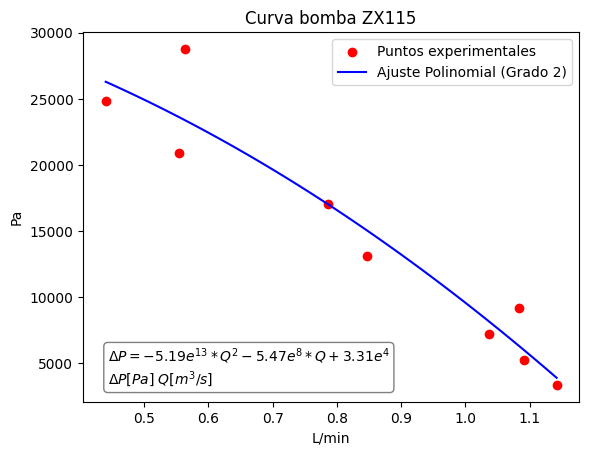

In [ ]:

plt.scatter(ndf["caudal"]*1000*60, ndf["dp"], color='red', label='Puntos experimentales')

# Dibujar curva ajustada
plt.plot(x_curva*1000*60, y_curva, '-', color='blue', label='Ajuste Polinomial (Grado 2)')
plt.ylabel("Pa")
plt.xlabel("L/min")
plt.legend()
plt.annotate(
text=r"$\Delta P = -1.23667290e11 * Q^2 - 5.47e^8 *Q + 3.31e^4$"+ "\n" + r"$\Delta P[Pa]$ $Q[m^3/s]$",
    xy=(0.05, 0.05),              # (X, Y) Posición: 5% a la derecha, 5% hacia arriba
    xycoords='axes fraction',     # Las coordenadas son relativas al tamaño del gráfico
    fontsize=10,                  # Opcional: tamaño de la letra
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1) # Opcional: le pone una cajita de fondo
)
plt.title("Curva bomba ZX115")
#plt.plot(x_curvap, y_curvap, '--', color='blue', label='Ajuste Polinomial (Grado 2)')